# Борьба с переобучением, улучшение качества классификации

**Содержание:**
- Группировка классов
- Class weights + weight decay
- Focal Loss
- Выводы и наблюдения

In [1]:
import pandas as pd
import numpy as np
import optuna
from sklearn.preprocessing import StandardScaler, LabelEncoder
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

from utils import plot_train_dynamics, create_sequences
from attention_gru import DetectorAttentionGRU

In [2]:
import warnings
for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category = warn)

In [3]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Группировка классов

In [4]:
data = pd.read_csv('Free_Text_EmoSurv.csv')

Исходные классы:

- `0`: Angry
- `1`: Calm
- `2`: Happy
- `3`: Neutral
- `4`: Sad

In [5]:
emotion_mapping = {
    0: 2,  # Angry -> Negative
    1: 1,  # Calm -> Positive
    2: 1,  # Happy -> Positive
    3: 0,  # Neutral -> Neutral
    4: 2   # Sad -> Negative
}

data['emotionIndex'] = data['emotionIndex'].map(emotion_mapping)

Теперь примерно поровну позитивного и негативного класса

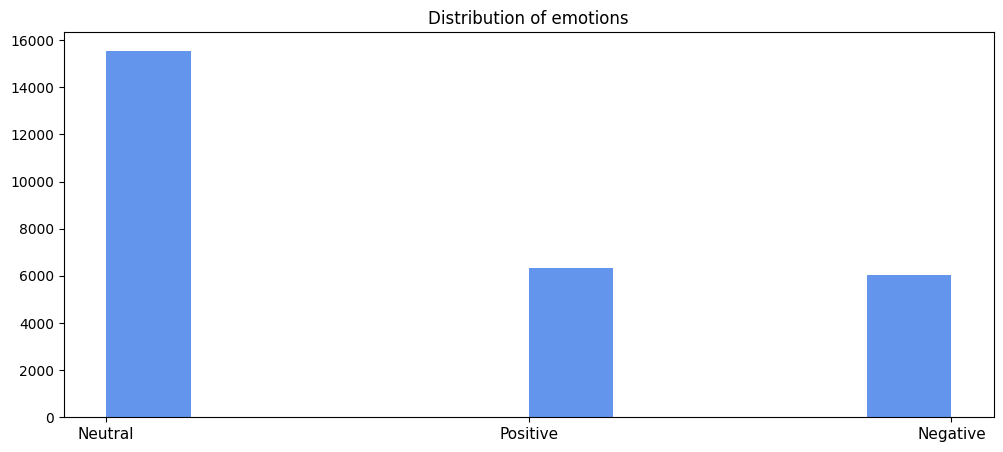

In [ ]:
plt.figure(figsize=(12, 5))
plt.title('Distribution of emotions')
plt.hist(data['emotionIndex'], color='cornflowerblue')
plt.xticks([0, 1, 2], ['Neutral', 'Positive', 'Negative'],fontsize=11)
plt.show()

In [7]:
users = data['userid'].unique().tolist()
train_users, test_users = train_test_split(users, test_size = 0.3, random_state = 0) # делим на train и test по пользователям

train_data = data[data['userid'].isin(train_users)].copy()
test_data = data[data['userid'].isin(test_users)].copy()

In [8]:
test_users, valid_users = train_test_split(test_users, test_size = 0.5, random_state = 0) # дополнительно выделим валидационную выборку

test_data = data[data['userid'].isin(test_users)].copy()
valid_data = data[data['userid'].isin(valid_users)].copy()

In [9]:
feature_cols = ['D1U1', 'D1U2', 'D1D2', 'U1D2', 'U1U2', 'D1U3', 'D1D3', 'is_punctuation', 'is_backspace', 'is_enter', 'hour']

scaler_X = StandardScaler()
train_data[feature_cols] = scaler_X.fit_transform(train_data[feature_cols])
test_data[feature_cols] = scaler_X.transform(test_data[feature_cols])
valid_data[feature_cols] = scaler_X.transform(valid_data[feature_cols])

In [10]:
SEQ_LEN = 32  # длина последовательности
STEP = 16     # шаг для последовательности
X_train, y_train = create_sequences(train_data, SEQ_LEN, STEP, is_train = True)
X_test, y_test = create_sequences(test_data, SEQ_LEN, STEP)
X_valid, y_valid = create_sequences(valid_data, SEQ_LEN, STEP)

## Cross Entropy + class weights + weight decay

In [ ]:
# вычисляем веса для классов (обратно пропорционально частоте)
class_weights = compute_class_weight(
    'balanced',
    classes=np.array([0, 1, 2]),
    y=y_train.numpy()
)
class_weights = torch.tensor(class_weights, dtype=torch.float)

In [12]:
class_weights

tensor([0.6160, 1.3652, 1.5524])

In [13]:
train_dataset = TensorDataset(X_train, y_train)
valid_dataset = TensorDataset(X_valid, y_valid)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)  
valid_loader = DataLoader(valid_dataset, batch_size = 16, shuffle = False) 
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False)   

In [14]:
def model_analysis(model, total_epochs, model_optimizer, criterion, focal_loss = False):
    train_f1 = []
    train_loss = []

    for epoch in range(total_epochs):
        model.train()
        total_loss = 0
        targets, predictions = [], []
        
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            model_optimizer.zero_grad()
            output = model(X_batch)
            
            if focal_loss == True:
                y_one_hot = F.one_hot(y_batch, num_classes=3).float() # конвертируем индексы в one-hot
                loss = criterion(output, y_one_hot)
            else:
                loss = criterion(output, y_batch)
            
            loss.backward()
            model_optimizer.step()

            preds = torch.argmax(output, dim = 1)
            total_loss += loss.item() * X_batch.size(0)
            targets.extend(y_batch.cpu().numpy())
            predictions.extend(preds.cpu().numpy())
        
        avg_loss = total_loss / len(train_loader.dataset)
        train_loss.append(avg_loss)
        f1 = f1_score(targets, predictions, average='macro')
        train_f1.append(f1)
        
        if epoch % 10 == 9 or epoch == 0:
            print(f'Epoch {epoch+1}/{total_epochs}, Loss: {avg_loss:.6f}')
        
    return train_loss, train_f1

**Упрощение архитектуры GRU для борьбы с переобучением:**

In [62]:
attn_model_bidirect = best_model = DetectorAttentionGRU(input_size = 11, hidden_size = 16, num_layers = 1,  num_classes = 3, dropout = 0.3, bidirectional = True).to(DEVICE)
optimizer = optim.Adam(attn_model_bidirect.parameters(), lr = 0.005, weight_decay = 1e-4)
criterion = nn.CrossEntropyLoss(weight = class_weights)

In [63]:
train_loss_attn_b, train_f1_attn_b = model_analysis(attn_model_bidirect, 40, optimizer, criterion)

Epoch 1/40, Loss: 1.096756
Epoch 10/40, Loss: 1.021796
Epoch 20/40, Loss: 0.984794
Epoch 30/40, Loss: 0.954900
Epoch 40/40, Loss: 0.927196


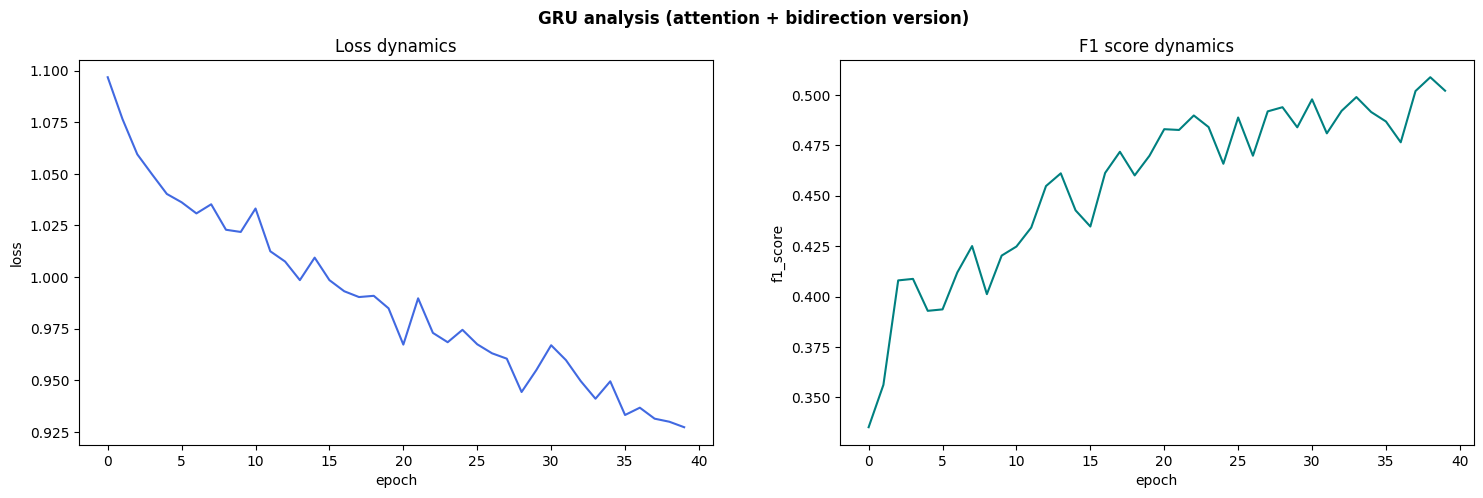

In [64]:
fig = plot_train_dynamics(attn_model_bidirect, train_loss_attn_b, train_f1_attn_b, 'GRU analysis (attention + bidirection version)')
plt.show(fig)

Как можем заметить, улучшения есть, но переобучение очень сильное

**macro F1:** $\quad 0.17 \longrightarrow 0.32 \: \: (+ 15\%)$

In [65]:
pred = attn_model_bidirect(X_test)       # логиты
y_pred = pred.argmax(dim=1).detach().cpu().numpy()

print(classification_report(y_test, y_pred, target_names=['Neutral', 'Positive', 'Negative']))

              precision    recall  f1-score   support

     Neutral       0.49      0.33      0.40        63
    Positive       0.47      0.18      0.26        45
    Negative       0.21      0.60      0.31        25

    accuracy                           0.33       133
   macro avg       0.39      0.37      0.32       133
weighted avg       0.43      0.33      0.33       133



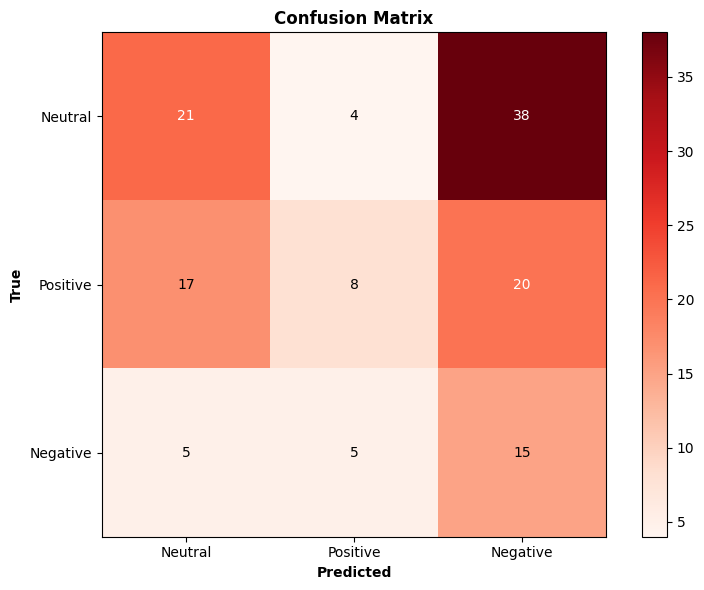

In [66]:
from sklearn.metrics import confusion_matrix

matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(matrix, interpolation='nearest', cmap='Reds')
plt.colorbar()

plt.xticks(range(len(matrix)), ['Neutral', 'Positive', 'Negative'])
plt.yticks(range(len(matrix)), ['Neutral', 'Positive', 'Negative'])
plt.xlabel("Predicted", fontweight='bold')
plt.ylabel("True", fontweight='bold')
plt.title("Confusion Matrix", fontweight='bold')

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        plt.text(
            j, i, str(matrix[i, j]),
            ha="center", va="center",
            color="white" if matrix[i, j] > matrix.max() / 2 else "black"
        )

plt.tight_layout()
plt.show()

- Модель все еще "боится" ошибаться на редком классе (большая часть предскзаний - негативный класс)
- Позитивный и нейтральный классы плохо распознаются

## Focal Loss

> Focal Loss —  функция потерь для решения проблемы сильного дисбаланса классов


- Модификация стандартного расчета функции потерь с целью снижения веса простых примеров. Это заставляет алгоритм оптимизации сосредоточить свою обучающую способность на сложных (трудноклассифицируемых) примерах, которые критически важны для производительности модели

- **Идея:** вводится коэффициент $\alpha$, который уменьшает вклад в потери по мере роста уверенности в правильном классе. Веса модели обновляются преимущественно на основе неверно классифицированных образцов или тех, в которых модель не уверена

In [140]:
class FocalLoss(nn.Module):
    def __init__(self, alpha = 0.25, gamma = 2.0, reduction = 'mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # inputs: [batch_size, num_classes]
        # targets: [batch_size, num_classes] - one-hot encoded
        probs = F.softmax(inputs, dim=1)
        
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        
        # pt - вероятность правильного класса
        pt = torch.sum(probs * targets, dim=1)  
        
        focal_weight = (1 - pt) ** self.gamma
        
        if self.alpha is not None:
            alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            alpha_t = torch.sum(alpha_t * targets, dim=1) 
            focal_weight = alpha_t * focal_weight
        
        focal_loss = focal_weight * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [153]:
attn_model_bidirect_f = DetectorAttentionGRU(input_size = 11, hidden_size = 16, num_layers = 1,  num_classes = 3, dropout = 0.3, bidirectional = True).to(DEVICE)
optimizer = optim.Adam(attn_model_bidirect_f.parameters(), lr = 0.001)
criterion_focal = FocalLoss(alpha = 0.05) 

train_loss_attn_bf, train_f1_attn_bf = model_analysis(attn_model_bidirect_f, 40, optimizer, criterion_focal, focal_loss = True)

Epoch 1/40, Loss: 0.025155
Epoch 10/40, Loss: 0.021150
Epoch 20/40, Loss: 0.020868
Epoch 30/40, Loss: 0.020482
Epoch 40/40, Loss: 0.020074


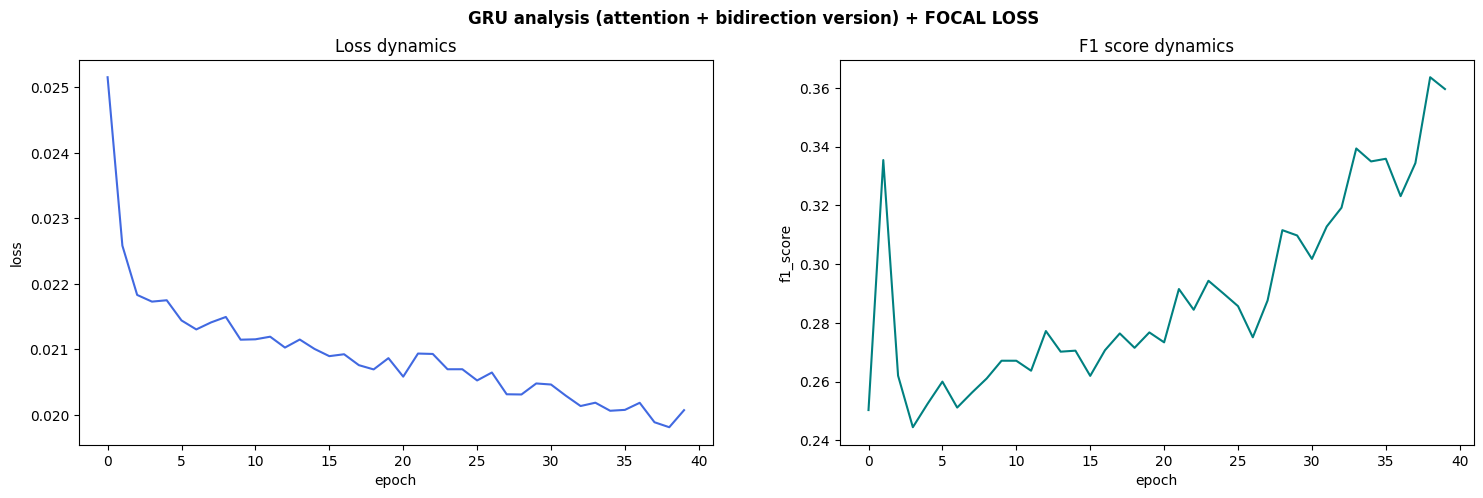

In [154]:
fig = plot_train_dynamics(attn_model_bidirect_f, train_loss_attn_bf, train_f1_attn_bf, 'GRU analysis (attention + bidirection version) + FOCAL LOSS')
plt.show(fig)

In [155]:
pred = attn_model_bidirect_f(X_test)       # логиты
y_pred = pred.argmax(dim=1).detach().cpu().numpy()

print(classification_report(y_test, y_pred, target_names=['Neutral', 'Positive', 'Negative']))

              precision    recall  f1-score   support

     Neutral       0.45      0.84      0.59        63
    Positive       0.00      0.00      0.00        45
    Negative       0.06      0.04      0.05        25

    accuracy                           0.41       133
   macro avg       0.17      0.29      0.21       133
weighted avg       0.23      0.41      0.29       133



In [156]:
def validate(model, val_loader):
    model.eval()  # режим оценки (выключаем dropout, batch norm)
    all_preds = []
    all_targets = []
    
    with torch.no_grad(): 
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            output = model(X_batch)  
            preds = torch.argmax(output, dim = 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())
    
    f1 = f1_score(all_targets, all_preds, average='macro')
    return f1

#### Подбор оптимального $\alpha$ по F1-score

In [188]:
def objective(trial):
    alpha = trial.suggest_float('alpha', 0.01, 1)

    model = DetectorAttentionGRU(input_size = 11, hidden_size = 16, num_layers = 1,  num_classes = 3, dropout = 0.3, bidirectional = True).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr = 0.001)
    criterion_focal = FocalLoss(alpha = alpha) 

    # обучаем с ранней остановкой 
    best_val_f1 = 0
    patience_counter = 0

    for epoch in range(30):
        model.train()
        for X_batch, y_batch in train_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                y_one_hot = F.one_hot(y_batch, num_classes=3).float() # конвертируем индексы в one-hot
        
                optimizer.zero_grad()
                output = model(X_batch)
                loss = criterion(output, y_one_hot)
                loss.backward()
                optimizer.step()
        
        # валидируем на каждой эпохе
        val_f1 = validate(model, valid_loader)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 4:
                break

    return best_val_f1


study = optuna.create_study(direction='maximize', study_name='FocalLoss_hyperparametrs')
optuna.logging.disable_default_handler()
study.optimize(objective, n_trials = 50)

trial = study.best_trial

print("Best F1 score: {}".format(trial.value))
print("Best hyperparameters: {}".format(trial.params))

Best F1 score: 0.4311868686868687
Best hyperparameters: {'alpha': 0.5319214922797539}


In [196]:
attn_model_bidirect_f = DetectorAttentionGRU(input_size = 11, hidden_size = 16, num_layers = 1,  num_classes = 3, dropout = 0.3, bidirectional = True).to(DEVICE)
optimizer = optim.Adam(attn_model_bidirect_f.parameters(), lr = 0.001)
criterion_focal = FocalLoss(**trial.params) 

train_loss_attn_bf, train_f1_attn_bf = model_analysis(attn_model_bidirect_f, 60, optimizer, criterion_focal, focal_loss = True)

Epoch 1/60, Loss: 0.252609
Epoch 10/60, Loss: 0.226607
Epoch 20/60, Loss: 0.222344
Epoch 30/60, Loss: 0.215365
Epoch 40/60, Loss: 0.212233
Epoch 50/60, Loss: 0.208088
Epoch 60/60, Loss: 0.204782


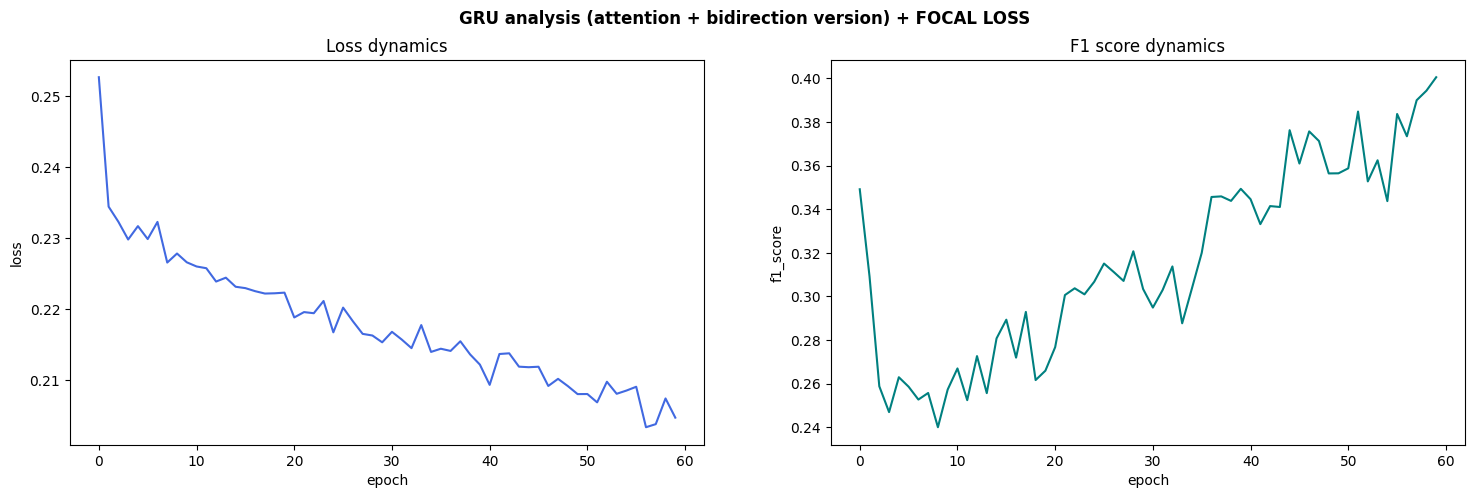

In [197]:
fig = plot_train_dynamics(attn_model_bidirect_f, train_loss_attn_bf, train_f1_attn_bf, 'GRU analysis (attention + bidirection version) + FOCAL LOSS')
plt.show(fig)

In [198]:
pred = attn_model_bidirect_f(X_test)       # логиты
y_pred = pred.argmax(dim=1).detach().cpu().numpy()

print(classification_report(y_test, y_pred, target_names=['Neutral', 'Positive', 'Negative']))

              precision    recall  f1-score   support

     Neutral       0.45      0.81      0.58        63
    Positive       0.33      0.02      0.04        45
    Negative       0.24      0.16      0.19        25

    accuracy                           0.42       133
   macro avg       0.34      0.33      0.27       133
weighted avg       0.37      0.42      0.32       133



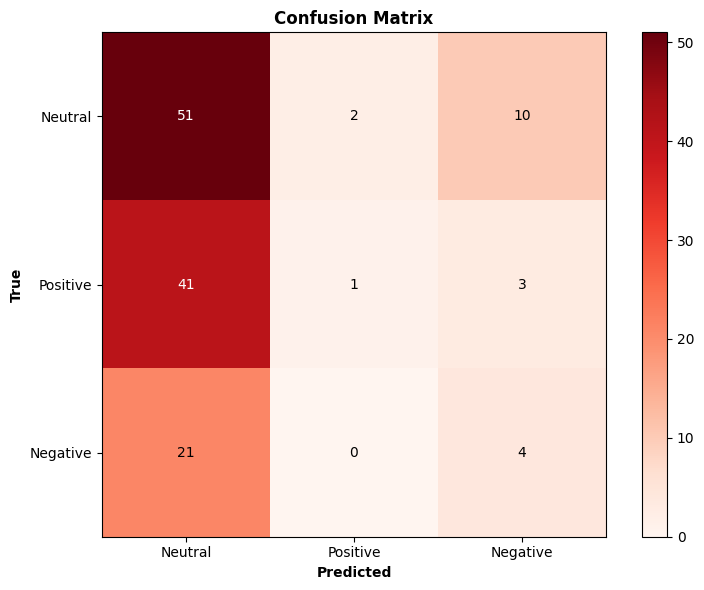

In [199]:
matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(matrix, interpolation='nearest', cmap='Reds')
plt.colorbar()

plt.xticks(range(len(matrix)), ['Neutral', 'Positive', 'Negative'])
plt.yticks(range(len(matrix)), ['Neutral', 'Positive', 'Negative'])
plt.xlabel("Predicted", fontweight='bold')
plt.ylabel("True", fontweight='bold')
plt.title("Confusion Matrix", fontweight='bold')

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        plt.text(
            j, i, str(matrix[i, j]),
            ha="center", va="center",
            color="white" if matrix[i, j] > matrix.max() / 2 else "black"
        )

plt.tight_layout()
plt.show()

## Выводы и наблюдения

**Cross Entropy + class weights + weight decay**
- Модель "боится" ошибаться на редких классах (Negative), поэтому часто жертвует Positive и Neutral ради Negative. Это видно по матрице ошибок

**Focal Loss**
- Модель начала предсказывать частый класс Neutral почти во всех случаях, остальные два класса практически не распознаются